<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/TimeA012.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TimeA012: Resonant Threshold Scan
Feedback | Entropy Slope | Memory Retention | Irreversibility Index | Resonance Amplitude
    0.00 |        0.24201 |           0.99822 |             130.46962 |              0.43474
    0.05 |       -0.08815 |           0.90112 |             156.16574 |              0.45707
    0.10 |       -0.08839 |           0.90220 |             154.49723 |              0.45303
    0.15 |       -0.08716 |           0.90060 |             155.21243 |              0.45315
    0.20 |       -0.08731 |           0.90111 |             154.75494 |              0.45521
    0.25 |       -0.08776 |           0.90130 |             154.33108 |              0.45981
    0.30 |       -0.08838 |           0.90149 |             156.09664 |              0.45972
    0.35 |       -0.08658 |           0.89997 |             155.42053 |              0.45258
    0.40 |       -0.08502 |           0.89965 |             154.00478 |              0.45638
    0.45 |       -0.08723 |           0

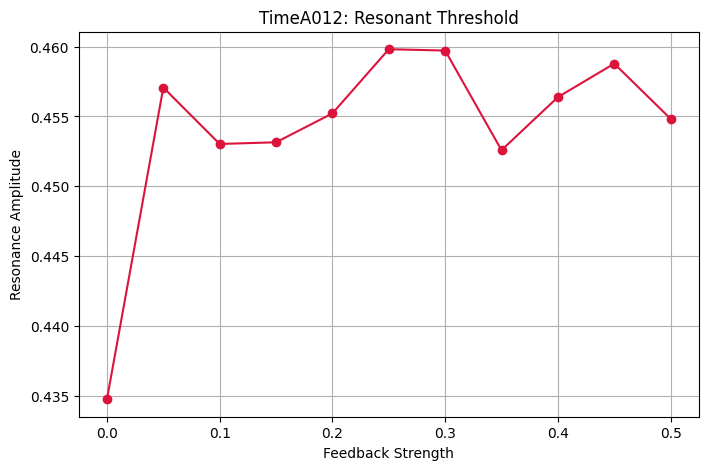

In [1]:
# 🔺 TimeA012: The Resonant Threshold
# Scanning feedback strength to detect phase transitions in HES lattice resonance
# Author: Chris & Copilot | Arc VI: Resonant Thresholds | ACT029
# Reproducibility Tag: TimeA012_v1

import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
N = 100
T = 200
bias_strength = 0.05
xi_locking = True
feedback_range = np.linspace(0.0, 0.5, 11)  # 0.0 to 0.5 in 0.05 steps
seed = 42
np.random.seed(seed)

# --- Curvature Profile: Exponential ---
def exponential_curvature(N):
    x = np.linspace(-1, 1, N)
    return -np.exp(-5 * x**2)[:, None]

# --- Initialization ---
def initialize_lattice(N):
    base = np.random.rand(N, N)
    curvature = exponential_curvature(N)
    return base + curvature

# --- Entropy Calculation ---
def compute_entropy(lattice):
    hist, _ = np.histogram(lattice, bins=50, density=True)
    hist = hist[hist > 0]
    return -np.sum(hist * np.log(hist))

# --- Evolution Function ---
def evolve_with_feedback(lattice, xi_locking, bias_strength, feedback_strength, past_entropy):
    entropy_map = np.gradient(lattice)[0]
    feedback_scalar = feedback_strength * (np.mean(past_entropy) if len(past_entropy) > 0 else 0)
    feedback_field = np.full_like(lattice, feedback_scalar)
    lattice += 0.01 * np.random.randn(*lattice.shape) + bias_strength * entropy_map + feedback_field
    if xi_locking:
        lattice = np.clip(lattice, 0.2, 0.8)
    return lattice

# --- Simulation Loop ---
def run_simulation(N, T, feedback_strength):
    lattice = initialize_lattice(N)
    entropy_series = []
    cumulative_drift = np.zeros_like(lattice)
    for t in range(T):
        prev_lattice = lattice.copy()
        past_entropy = np.array(entropy_series[-10:]) if len(entropy_series) >= 10 else np.zeros(10)
        lattice = evolve_with_feedback(lattice, xi_locking, bias_strength, feedback_strength, past_entropy)
        cumulative_drift += lattice - prev_lattice
        S = compute_entropy(lattice)
        entropy_series.append(S)
    return np.array(entropy_series), cumulative_drift

# --- Metrics ---
def compute_metrics(entropy_series, cumulative_drift):
    slope = np.polyfit(np.arange(len(entropy_series)), entropy_series, 1)[0]
    memory = np.corrcoef(entropy_series[:-1], entropy_series[1:])[0,1]
    irreversibility_index = np.sum(np.abs(np.diff(entropy_series)))
    resonance_amplitude = np.std(cumulative_drift)
    return slope, memory, irreversibility_index, resonance_amplitude

# --- Run Scan ---
results = []
for f in feedback_range:
    entropy_series, drift = run_simulation(N, T, f)
    metrics = compute_metrics(entropy_series, drift)
    results.append((f,) + metrics)

# --- Output ---
print("TimeA012: Resonant Threshold Scan")
print("Feedback | Entropy Slope | Memory Retention | Irreversibility Index | Resonance Amplitude")
for r in results:
    print(f"{r[0]:>8.2f} | {r[1]:>14.5f} | {r[2]:>17.5f} | {r[3]:>21.5f} | {r[4]:>20.5f}")

# --- Plotting ---
feedback_vals = [r[0] for r in results]
resonance_vals = [r[4] for r in results]
plt.figure(figsize=(8,5))
plt.plot(feedback_vals, resonance_vals, marker='o', color='crimson')
plt.xlabel('Feedback Strength')
plt.ylabel('Resonance Amplitude')
plt.title('TimeA012: Resonant Threshold')
plt.grid(True)
plt.show()
